In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

BASE = '/content/drive/MyDrive/cryptocurrency-analysis'
PROC = os.path.join(BASE, 'data/processed')
FIGS = os.path.join(BASE, 'outputs/figures')
os.makedirs(FIGS, exist_ok=True)

print("Ready.")

Mounted at /content/drive
Ready.


In [2]:
#load data
# Load the processed file saved by Objective 3
try:
    df_all = pd.read_csv(os.path.join(PROC, 'all_coins_clean.csv'), parse_dates=['Date'])
    print(f"Loaded processed file — {df_all.shape}")
except FileNotFoundError:
    # Fallback: load directly from raw
    df_all = pd.read_csv(os.path.join(BASE, 'data/raw/coin_Bitcoin.csv'), parse_dates=['Date'])
    df_all['Coin'] = 'Bitcoin'
    print("Loaded raw Bitcoin file as fallback.")

# Work with Bitcoin for classification
df = df_all[df_all['Coin'] == 'Bitcoin'].copy()
df.sort_values('Date', inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Bitcoin rows: {len(df)} | Date range: {df['Date'].min()} → {df['Date'].max()}")

Loaded processed file — (37082, 11)
Bitcoin rows: 2991 | Date range: 2013-04-29 23:59:59 → 2021-07-06 23:59:59


In [3]:
#manually calculating technical indicators
#1. RSI (Relative Strength Index) — 14 day
def compute_rsi(series, period=14):
    delta = series.diff()
    gain  = delta.clip(lower=0)
    loss  = -delta.clip(upper=0)
    avg_gain = gain.rolling(window=period).mean()
    avg_loss = loss.rolling(window=period).mean()
    rs  = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

#2. MACD (Moving Average Convergence Divergence)
def compute_macd(series, fast=12, slow=26, signal=9):
    ema_fast   = series.ewm(span=fast, adjust=False).mean()
    ema_slow   = series.ewm(span=slow, adjust=False).mean()
    macd_line  = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    histogram  = macd_line - signal_line
    return macd_line, signal_line, histogram

#3. Bollinger Bands (20 day)
def compute_bollinger(series, period=20):
    sma        = series.rolling(window=period).mean()
    std        = series.rolling(window=period).std()
    upper_band = sma + (2 * std)
    lower_band = sma - (2 * std)
    # %B: where price is within the bands (0=lower, 1=upper)
    pct_b      = (series - lower_band) / (upper_band - lower_band)
    bandwidth  = (upper_band - lower_band) / sma
    return upper_band, lower_band, pct_b, bandwidth

#4. Moving Averages
def compute_sma(series, period):
    return series.rolling(window=period).mean()

#Apply all indicators
df['RSI']= compute_rsi(df['Close'])
df['MACD'], df['MACD_Signal'], df['MACD_Hist']= compute_macd(df['Close'])
df['BB_Upper'], df['BB_Lower'], df['BB_PctB'], df['BB_Width'] = compute_bollinger(df['Close'])
df['SMA_7']   = compute_sma(df['Close'], 7)
df['SMA_21']  = compute_sma(df['Close'], 21)
df['SMA_50']  = compute_sma(df['Close'], 50)

#Extra features
df['Daily_Return']= df['Close'].pct_change()
df['Volatility_7d']= df['Daily_Return'].rolling(7).std()
df['Volume_Change']= df['Volume'].pct_change()
df['Price_vs_SMA21']= (df['Close'] - df['SMA_21']) / df['SMA_21']  # how far price is from SMA21

print("All indicators computed.")
print(df[['Date','Close','RSI','MACD','BB_PctB','SMA_7','SMA_21']].tail(5))

All indicators computed.
                    Date         Close        RSI         MACD   BB_PctB  \
2986 2021-07-02 23:59:59  33897.048590  44.620040 -1179.730837  0.363588   
2987 2021-07-03 23:59:59  34668.548402  47.392762 -1071.555752  0.454028   
2988 2021-07-04 23:59:59  35287.779766  48.902593  -925.194358  0.545203   
2989 2021-07-05 23:59:59  33746.002456  56.377263  -922.971007  0.388747   
2990 2021-07-06 23:59:59  34235.193451  55.444147  -871.687094  0.482241   

             SMA_7        SMA_21  
2986  34235.434114  35363.368575  
2987  34590.044219  35321.274825  
2988  34681.206387  35139.842390  
2989  34582.873122  34831.629276  
2990  34349.646795  34537.768536  


Sentiment Distribution:
Sentiment
Neutral    1433
Bullish     857
Bearish     700
Name: count, dtype: int64



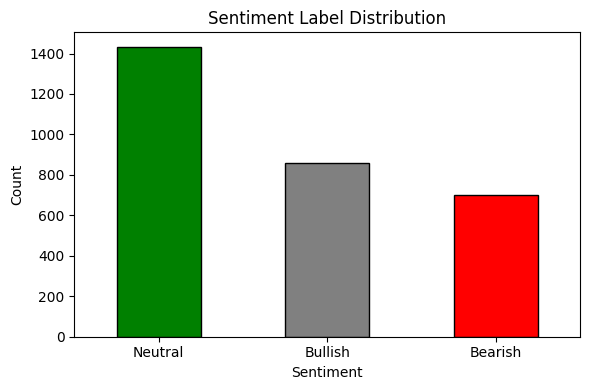

Saved: sentiment distribution


In [5]:
#label days as bullish, bearish or neutral
# Label based on next-day return
# Logic: look at the NEXT day's return to label TODAY's market signal
# Bullish: next day return > +1.5%
# Bearish:next day return < -1.5%
# Neutral:everything in between

THRESHOLD = 0.015  # 1.5%

df['Next_Return'] = df['Daily_Return'].shift(-1)

def label_day(ret):
    if pd.isna(ret):
        return np.nan
    elif ret > THRESHOLD:
        return 'Bullish'
    elif ret < -THRESHOLD:
        return 'Bearish'
    else:
        return 'Neutral'

df['Sentiment'] = df['Next_Return'].apply(label_day)

#Class distribution
print("Sentiment Distribution:")
print(df['Sentiment'].value_counts())
print()

plt.figure(figsize=(6, 4))
df['Sentiment'].value_counts().plot(
    kind='bar',
    color=['green', 'gray', 'red'],
    edgecolor='black'
)
plt.title('Sentiment Label Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'sentiment_distribution.png'))
plt.show()
print("Saved: sentiment distribution")

In [8]:
#prepare features for ml
FEATURES = [
    'RSI',
    'MACD',
    'MACD_Signal',
    'MACD_Hist',
    'BB_PctB',
    'BB_Width',
    'SMA_7',
    'SMA_21',
    'SMA_50',
    'Daily_Return',
    'Volatility_7d',
    'Volume_Change',
    'Price_vs_SMA21'
]

TARGET = 'Sentiment'

# Drop rows with NaN (from rolling windows / shift)
df_ml = df[FEATURES + [TARGET]].replace([np.inf, -np.inf], np.nan).dropna()
print(f"Rows after dropping NaN: {len(df_ml)}")

X = df_ml[FEATURES]
y = df_ml[TARGET]

#Train / Test split (80/20, no shuffle)#time series order matters
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)
print(f"Train: {len(X_train)} rows | Test: {len(X_test)} rows")

#Scale features (important for Logistic Regression)
scaler  = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("Data ready for modelling.")

Rows after dropping NaN: 2747
Train: 2197 rows | Test: 550 rows
Data ready for modelling.


LOGISTIC REGRESSION — Classification Report
              precision    recall  f1-score   support

     Bearish       0.27      0.55      0.36       128
     Bullish       0.39      0.33      0.35       172
     Neutral       0.61      0.36      0.45       250

    accuracy                           0.39       550
   macro avg       0.42      0.41      0.39       550
weighted avg       0.46      0.39      0.40       550



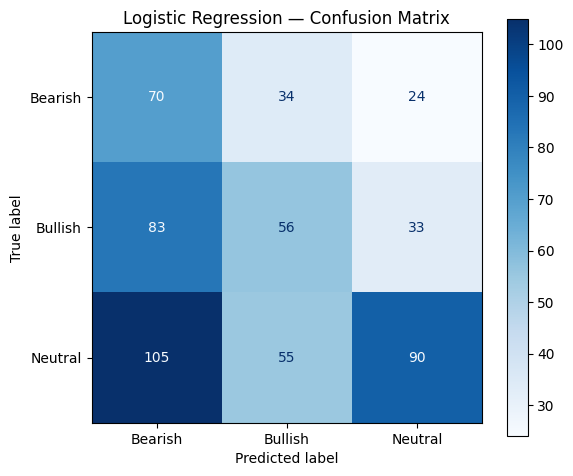

Saved: LR confusion matrix


In [10]:
#logistic regression
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

print("LOGISTIC REGRESSION — Classification Report")
print(classification_report(y_test, y_pred_lr))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=lr.classes_,
    cmap='Blues', ax=ax
)
ax.set_title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'confusion_matrix_lr.png'))
plt.show()
print("Saved: LR confusion matrix")

DECISION TREE — Classification Report
              precision    recall  f1-score   support

     Bearish       0.21      0.46      0.28       128
     Bullish       0.35      0.45      0.39       172
     Neutral       0.62      0.10      0.17       250

    accuracy                           0.29       550
   macro avg       0.39      0.34      0.28       550
weighted avg       0.44      0.29      0.26       550



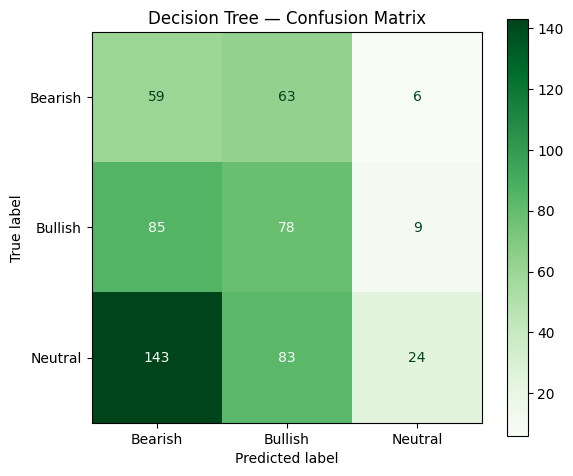

Saved: DT confusion matrix


In [12]:
#decision tree classifier
dt = DecisionTreeClassifier(
    max_depth=5,
    class_weight='balanced',
    random_state=42
)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("DECISION TREE — Classification Report")
print(classification_report(y_test, y_pred_dt))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dt,
    display_labels=dt.classes_,
    cmap='Greens', ax=ax
)
ax.set_title('Decision Tree — Confusion Matrix')
plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'confusion_matrix_dt.png'))
plt.show()
print("Saved: DT confusion matrix")

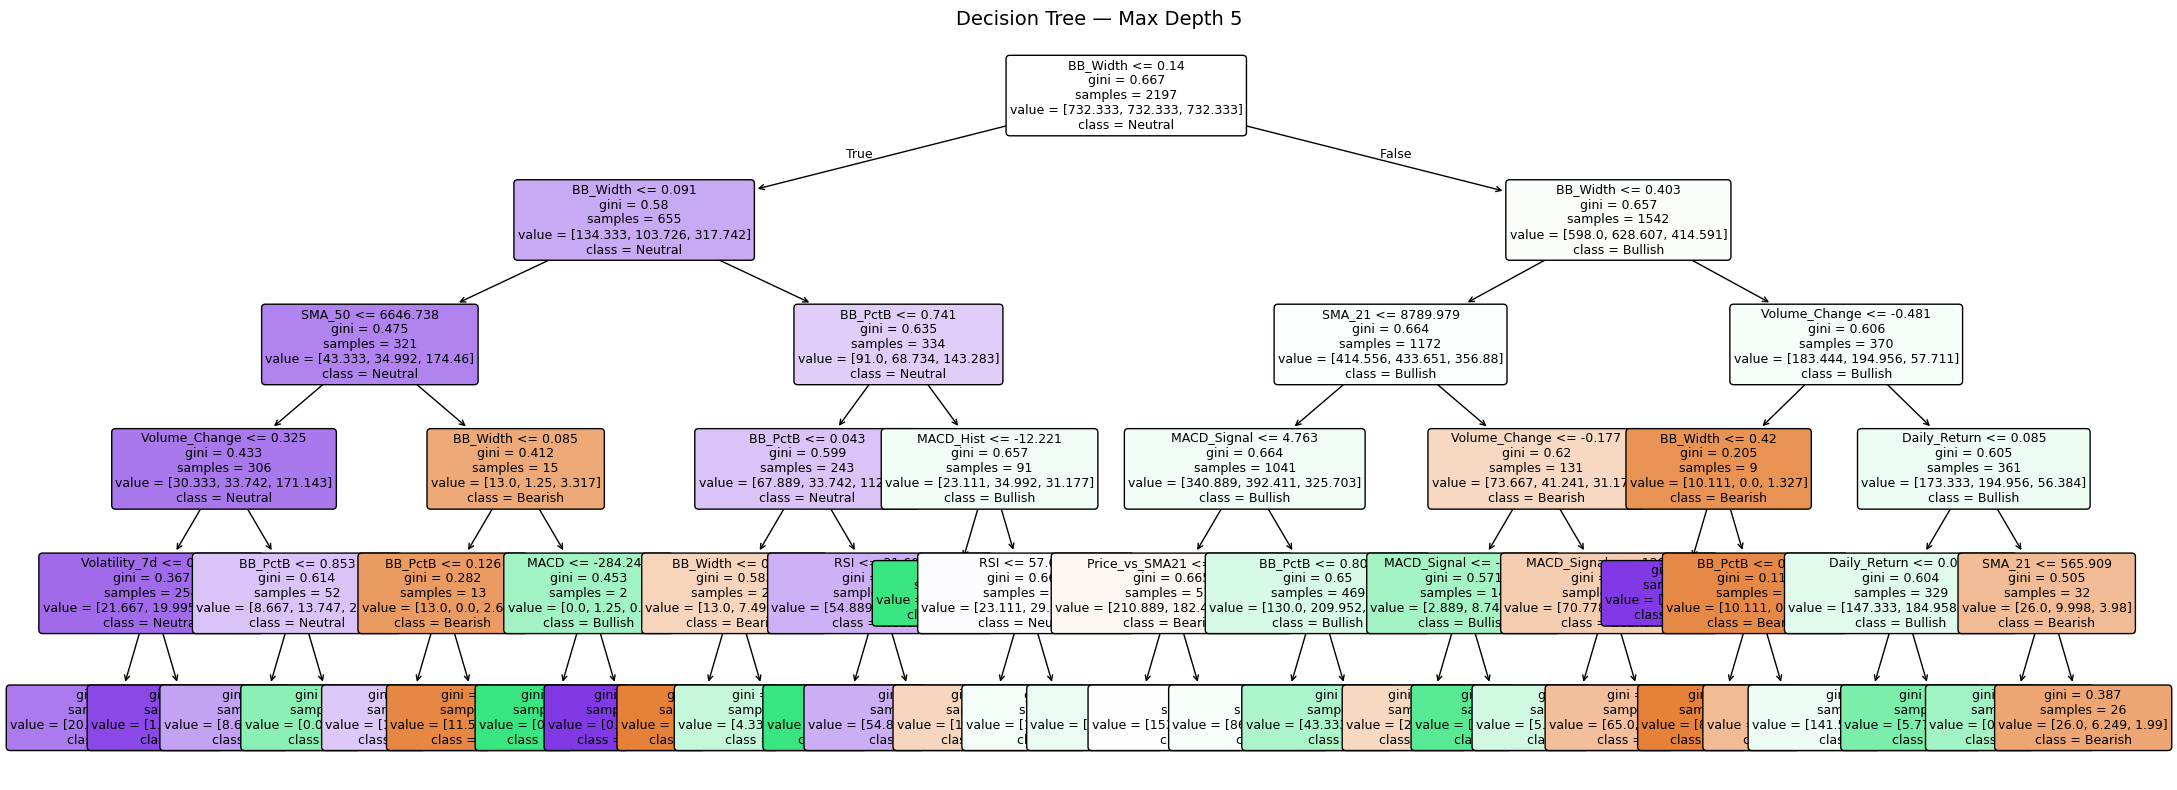

Saved: decision tree plot


In [14]:
#visualize decision tree
plt.figure(figsize=(22, 8))
plot_tree(
    dt,
    feature_names=FEATURES,
    class_names=dt.classes_,
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title('Decision Tree — Max Depth 5', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'decision_tree_plot.png'))
plt.show()
print("Saved: decision tree plot")

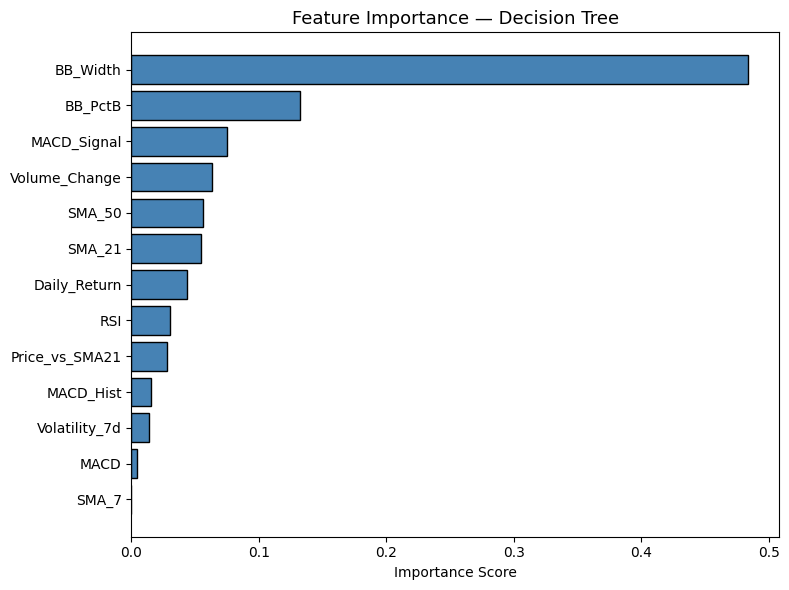

Saved: feature importance


In [16]:
#feature importance
importance_df = pd.DataFrame({
    'Feature'   : FEATURES,
    'Importance': dt.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'],
         color='steelblue', edgecolor='black')
plt.title('Feature Importance — Decision Tree', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'feature_importance.png'))
plt.show()
print("Saved: feature importance")

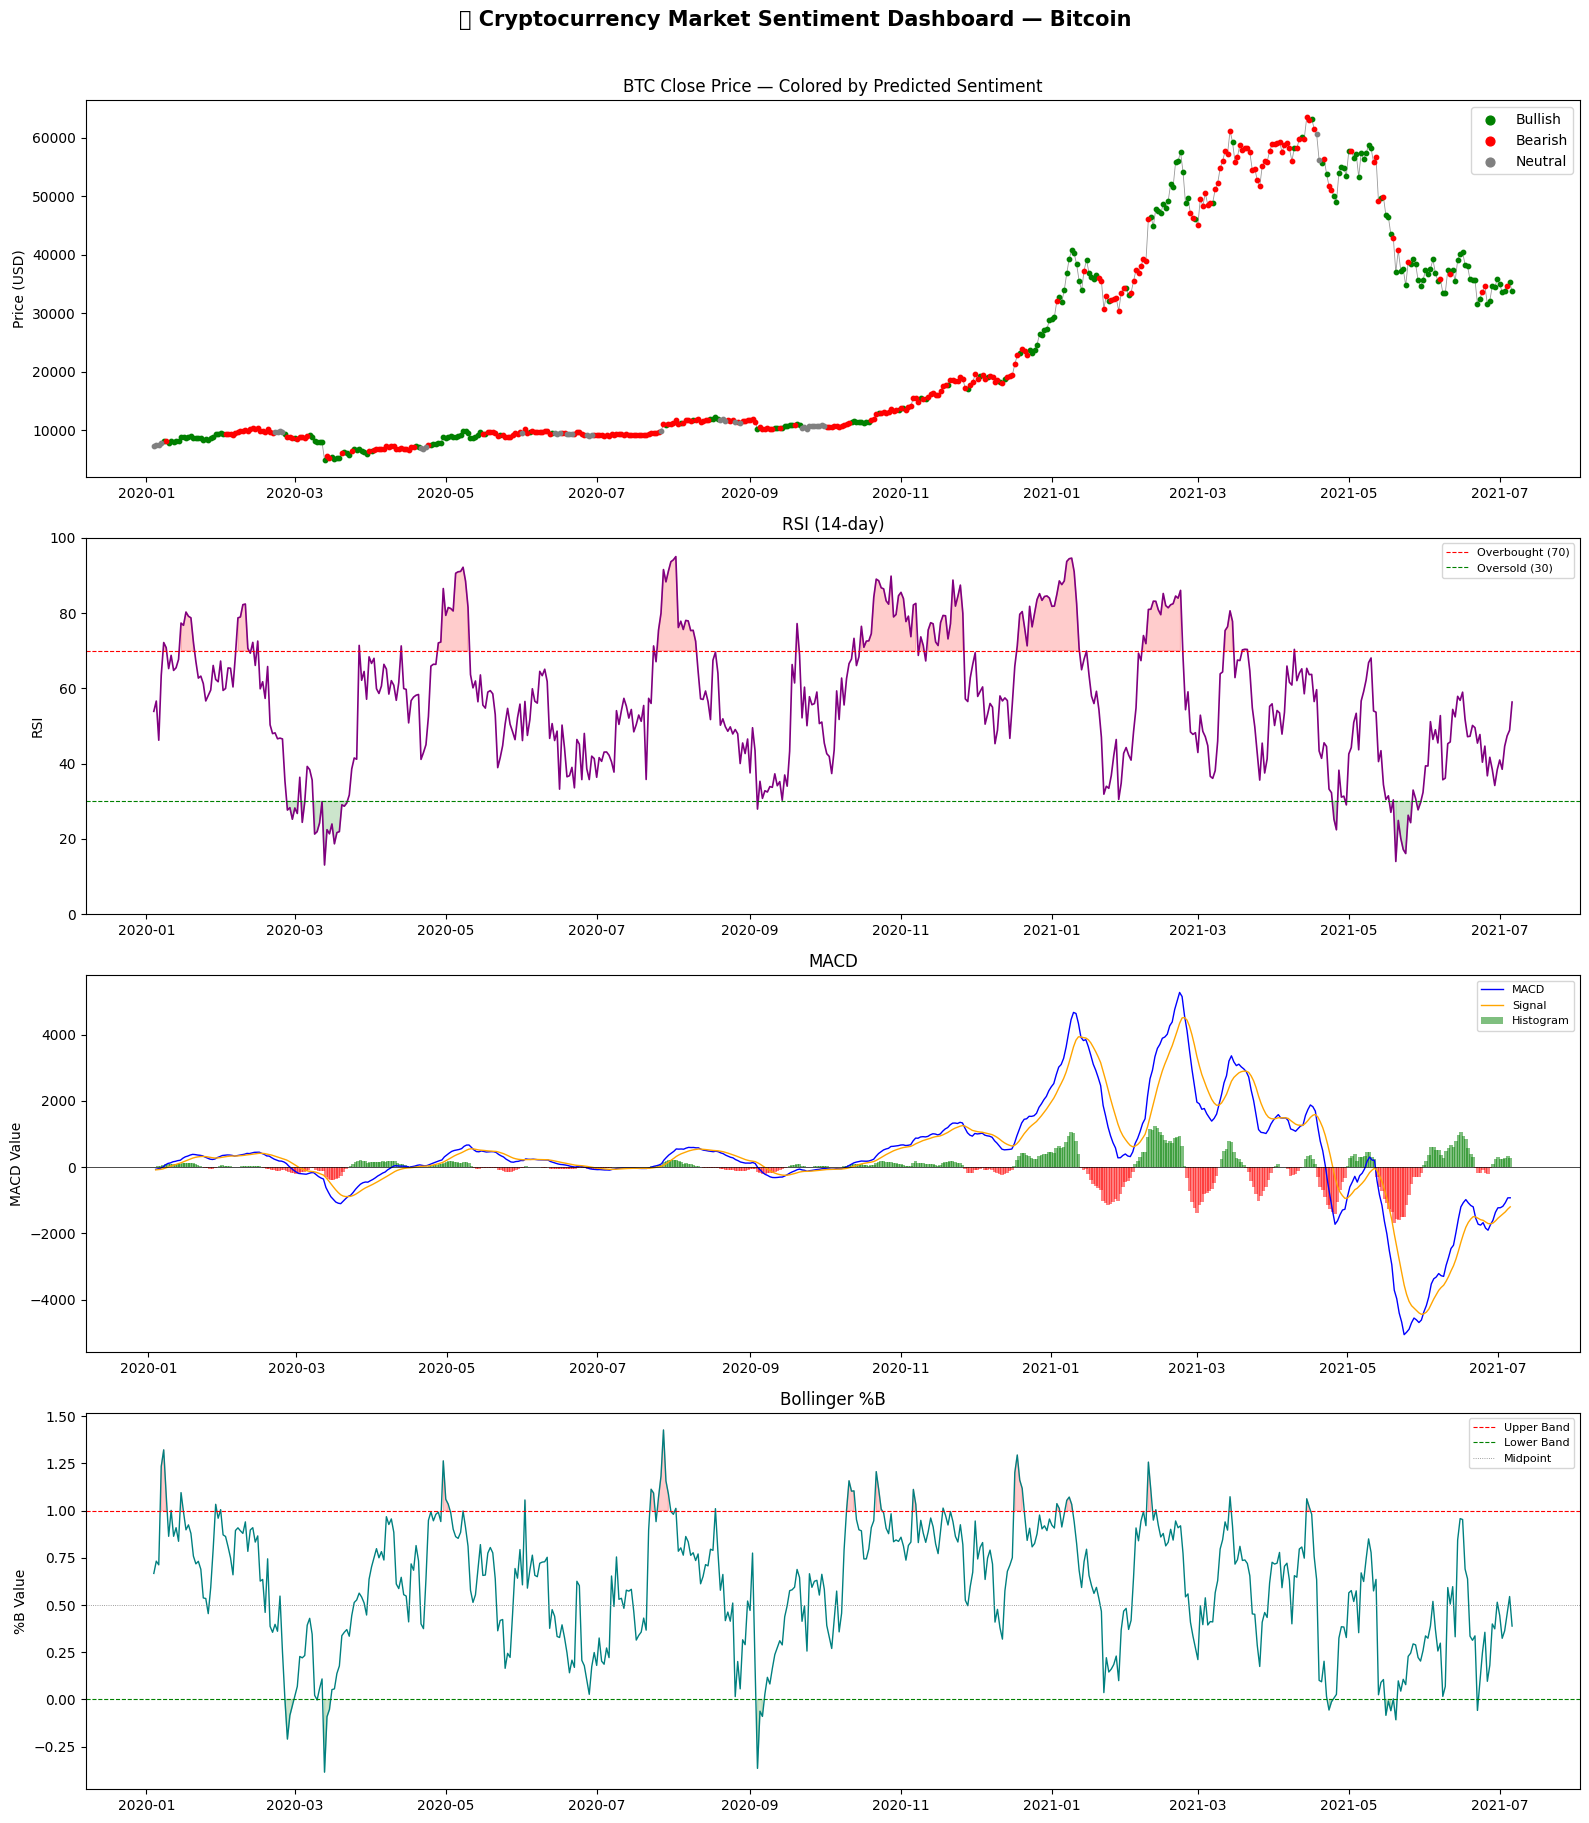

Saved: full sentiment dashboard


In [18]:
#static dashboard
#Merge predictions back onto the original date axis
result_df = df_ml.copy()
result_df = result_df.iloc[len(X_train):]   # test portion only
result_df['Predicted'] = y_pred_dt
result_df['Date'] = df.loc[result_df.index, 'Date'].values
result_df['Close'] = df.loc[result_df.index, 'Close'].values

color_map = {'Bullish': 'green', 'Bearish': 'red', 'Neutral': 'gray'}

fig, axes = plt.subplots(4, 1, figsize=(16, 18), sharex=False)
fig.suptitle('📊 Cryptocurrency Market Sentiment Dashboard — Bitcoin',
             fontsize=15, fontweight='bold', y=1.01)

#Panel 1: Price + Sentiment coloring
ax1 = axes[0]
for sentiment, color in color_map.items():
    mask = result_df['Predicted'] == sentiment
    ax1.scatter(result_df.loc[mask, 'Date'],
                result_df.loc[mask, 'Close'],
                c=color, s=10, label=sentiment, zorder=3)
ax1.plot(result_df['Date'], result_df['Close'],
         color='black', linewidth=0.6, alpha=0.4)
ax1.set_title('BTC Close Price — Colored by Predicted Sentiment')
ax1.set_ylabel('Price (USD)')
ax1.legend(markerscale=2)

#Panel 2: RSI
ax2 = axes[1]
ax2.plot(result_df['Date'], result_df['RSI'],
         color='purple', linewidth=1.2)
ax2.axhline(70, color='red',   linestyle='--', linewidth=0.8, label='Overbought (70)')
ax2.axhline(30, color='green', linestyle='--', linewidth=0.8, label='Oversold (30)')
ax2.fill_between(result_df['Date'], result_df['RSI'], 70,
                 where=(result_df['RSI'] >= 70), alpha=0.2, color='red')
ax2.fill_between(result_df['Date'], result_df['RSI'], 30,
                 where=(result_df['RSI'] <= 30), alpha=0.2, color='green')
ax2.set_title('RSI (14-day)')
ax2.set_ylabel('RSI')
ax2.set_ylim(0, 100)
ax2.legend(fontsize=8)

# Panel 3: MACD
ax3 = axes[2]
ax3.plot(result_df['Date'], result_df['MACD'],
         label='MACD', color='blue', linewidth=1)
ax3.plot(result_df['Date'], result_df['MACD_Signal'],
         label='Signal', color='orange', linewidth=1)
ax3.bar(result_df['Date'], result_df['MACD_Hist'],
        label='Histogram',
        color=result_df['MACD_Hist'].apply(
            lambda x: 'green' if x >= 0 else 'red'),
        alpha=0.5, width=1.5)
ax3.axhline(0, color='black', linewidth=0.5)
ax3.set_title('MACD')
ax3.set_ylabel('MACD Value')
ax3.legend(fontsize=8)

#Panel 4: Bollinger %B
ax4 = axes[3]
ax4.plot(result_df['Date'], result_df['BB_PctB'],
         color='teal', linewidth=1)
ax4.axhline(1.0, color='red',   linestyle='--', linewidth=0.8, label='Upper Band')
ax4.axhline(0.0, color='green', linestyle='--', linewidth=0.8, label='Lower Band')
ax4.axhline(0.5, color='gray',  linestyle=':',  linewidth=0.6, label='Midpoint')
ax4.fill_between(result_df['Date'], result_df['BB_PctB'], 1,
                 where=(result_df['BB_PctB'] >= 1), alpha=0.2, color='red')
ax4.fill_between(result_df['Date'], result_df['BB_PctB'], 0,
                 where=(result_df['BB_PctB'] <= 0), alpha=0.2, color='green')
ax4.set_title('Bollinger %B')
ax4.set_ylabel('%B Value')
ax4.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'sentiment_dashboard.png'),
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved: full sentiment dashboard")

In [20]:
#model comparison
from sklearn.metrics import accuracy_score, f1_score

summary = pd.DataFrame({
    'Model'   : ['Logistic Regression', 'Decision Tree'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt)
    ],
    'F1 (weighted)': [
        f1_score(y_test, y_pred_lr, average='weighted'),
        f1_score(y_test, y_pred_dt, average='weighted')
    ]
})

print("MODEL COMPARISON SUMMARY")
print(summary.to_string(index=False))

summary.to_csv(os.path.join(PROC, '04_model_summary.csv'), index=False)
print("Saved: model comparison summary")

MODEL COMPARISON SUMMARY
              Model  Accuracy  F1 (weighted)
Logistic Regression  0.392727       0.400990
      Decision Tree  0.292727       0.264864
Saved: model comparison summary
